# Sparse Modeling

Sparse Modeling is a family of machine learning techniques that assume that only a small number of features or parameters are actually important.

Instead of using every available feature, sparse models try to learn solutions where many coefficients are exactly zero.

This makes models:

- simpler
- more interpretable
- less prone to overfitting
- useful for high-dimensional data
- capable of performing feature selection

Common sparse modeling techniques include:

1. Lasso Regression
2. Elastic Net
3. Sparse Linear Regression
4. Basis Pursuit
5. Sparse Coding
6. Orthogonal Matching Pursuit (OMP)

The central idea is:

$$
\text{Learn a model with many coefficients equal to zero}
$$

Sparse modeling is especially useful when:

- the number of features is very large
- only a small subset of features is relevant
- interpretability is important
- feature selection is required

## 1. Why Sparse Modeling?

Consider a dataset with:

$$
n = 100
$$

samples and

$$
d = 10,000
$$

features.

A traditional linear model learns:

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_{10000}x_{10000}
$$

This gives us 10,000 coefficients.

However, suppose only 20 features actually contain useful information.

Then the ideal model would look like:

$$
y =
\beta_0
+
\beta_5x_5
+
\beta_{120}x_{120}
+
\beta_{742}x_{742}
+\cdots
$$

while most coefficients are zero:

$$
\beta_j = 0
$$

for most values of $j$.

This is called a **sparse solution**.

Sparse modeling tries to discover this smaller set of important features automatically.

## 2. Dense vs Sparse Models

### Dense Model

A dense model uses many features:

$$
\beta =
[\beta_1,\beta_2,\beta_3,\ldots,\beta_d]
$$

Most coefficients are non-zero.

Example:

$$
\beta =
[2.1,-0.7,1.5,0.4,-1.2,0.8,\ldots]
$$

### Sparse Model

A sparse model contains many zeros:

$$
\beta =
[2.1,0,0,0.4,0,0,\ldots]
$$

Only a small number of coefficients are non-zero.

### Key idea

$$
\boxed{\text{Sparse model} = \text{few non-zero parameters}}
$$

## 4. Lasso Regression

Lasso stands for:

**Least Absolute Shrinkage and Selection Operator**

Lasso adds an $L_1$ penalty to the objective function.

The optimization problem is:

$$
\min_{\beta}
\frac{1}{2}
\|y-X\beta\|_2^2
+
\lambda\|\beta\|_1
$$

where:

$$
\|\beta\|_1
=
\sum_{j=1}^{d}|\beta_j|
$$

Therefore:

$$
\min_{\beta}
\frac{1}{2}
\|y-X\beta\|_2^2
+
\lambda
\sum_{j=1}^{d}|\beta_j|
$$

The parameter $\lambda$ controls the strength of sparsity.

- Small $\lambda$ → weaker regularization
- Large $\lambda$ → stronger regularization
- Very large $\lambda$ → many coefficients become zero

## 5. Why Does $L_1$ Regularization Produce Sparsity?

The $L_1$ penalty is:

$$
\|\beta\|_1
=
\sum_j|\beta_j|
$$

Unlike the $L_2$ penalty, the $L_1$ penalty has a sharp corner at zero.

This encourages optimization solutions to land exactly on zero.

Therefore:

$$
L_1
\Rightarrow
\text{many coefficients become exactly zero}
$$

while:

$$
L_2
\Rightarrow
\text{coefficients become small but usually not exactly zero}
$$

This is why Lasso can perform **feature selection** automatically.

## 6. Lasso as Feature Selection

Suppose we have 10 features.

After fitting a Lasso model:

$$
\beta =
[2.31,0,0,-1.42,0,0,0.87,0,0,0]
$$

Only three features have non-zero coefficients.

Therefore:

$$
\text{Selected Features}
=
\{X_1,X_4,X_7\}
$$

The remaining features have coefficients equal to zero.

Thus Lasso performs two tasks simultaneously:

1. Prediction
2. Feature selection

This is one of the most important applications of sparse modeling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score

## 7. Creating a Sparse Dataset

We will create a regression dataset containing:

- 200 samples
- 50 features
- only 5 informative features

This gives us a controlled environment for studying sparse modeling.

In [2]:
X, y, true_coef = make_regression(
    n_samples=200,
    n_features=50,
    n_informative=5,
    noise=10,
    coef=True,
    random_state=42
)

X.shape, y.shape

((200, 50), (200,))

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Ordinary Linear Regression

First, we train a normal linear regression model.

This gives us a baseline for comparison with Lasso.

In [4]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression MSE:", linear_mse)
print("Linear Regression R²:", linear_r2)

Linear Regression MSE: 152.35903665025768
Linear Regression R²: 0.9737750530893123


In [5]:
linear_nonzero = np.sum(np.abs(linear_model.coef_) > 1e-6)

print("Number of non-zero coefficients:", linear_nonzero)
print("Total features:", X.shape[1])

Number of non-zero coefficients: 50
Total features: 50


## 9. Training a Lasso Model

Now we introduce sparsity using Lasso.

The optimization objective is:

$$
\min_{\beta}
\frac{1}{2}
\|y-X\beta\|_2^2
+
\lambda\|\beta\|_1
$$

We will start with:

$$
\lambda = 1
$$

In [6]:
lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso MSE:", lasso_mse)
print("Lasso R²:", lasso_r2)

Lasso MSE: 126.18186586958034
Lasso R²: 0.9782808239913109


In [7]:
lasso_nonzero = np.sum(np.abs(lasso.coef_) > 1e-6)

print("Number of non-zero coefficients:", lasso_nonzero)
print("Total features:", X.shape[1])

Number of non-zero coefficients: 11
Total features: 50


## 10. Visualizing Lasso Coefficients

A sparse model should contain many coefficients close to or exactly equal to zero.

We can visualize the learned coefficients.    

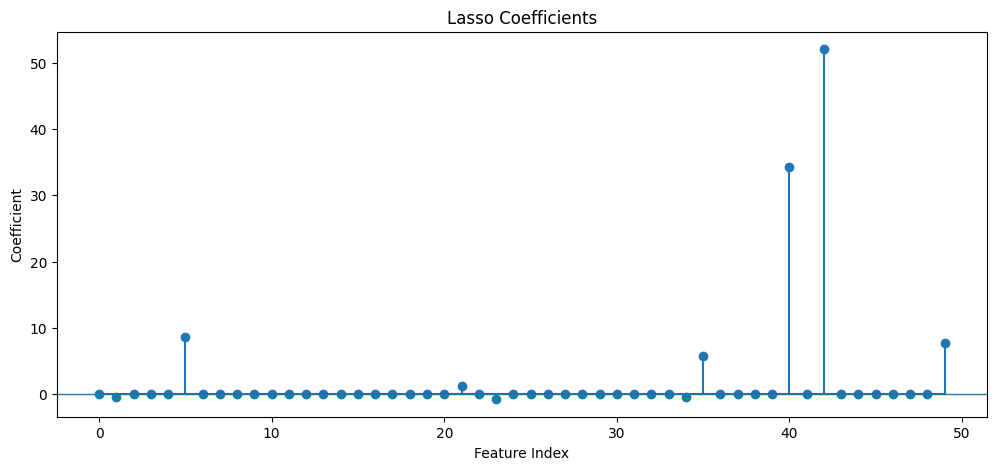

In [8]:
plt.figure(figsize=(12, 5))

plt.stem(
    range(len(lasso.coef_)),
    lasso.coef_
)

plt.axhline(0, linewidth=1)

plt.xlabel("Feature Index")
plt.ylabel("Coefficient")
plt.title("Lasso Coefficients")

plt.show()

## 11. Effect of $\lambda$

The regularization parameter controls sparsity.

Recall:

$$
\min_{\beta}
\frac{1}{2}
\|y-X\beta\|_2^2
+
\lambda\|\beta\|_1
$$

As $\lambda$ increases:

$$
\lambda \uparrow
\Rightarrow
\text{stronger regularization}
$$

which generally produces:

$$
\text{more coefficients} = 0
$$

However, excessive regularization can cause underfitting.

In [9]:
alphas = [0.01, 0.1, 0.5, 1, 2, 5, 10]

results = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    results.append({
        "alpha": alpha,
        "MSE": mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "Non-zero coefficients": np.sum(np.abs(model.coef_) > 1e-6)
    })

results_df = pd.DataFrame(results)

results_df

,alpha,MSE,R2,Non-zero coefficients
0,0.01,151.368058,0.973946,47
1,0.10,143.333639,0.975329,44
2,0.50,128.231669,0.977928,21
3,1.00,126.181866,0.978281,11
4,2.00,143.455861,0.975308,6
5,5.00,301.500248,0.948104,5
6,10.00,708.779192,0.878001,2


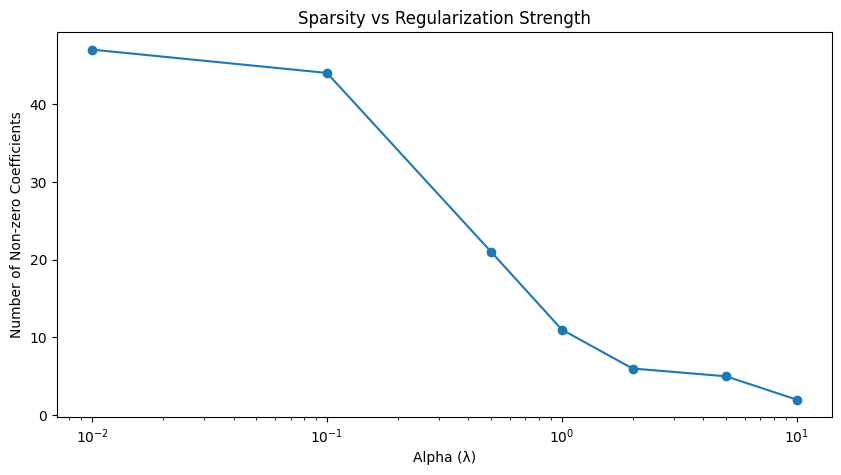

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["alpha"],
    results_df["Non-zero coefficients"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha (λ)")
plt.ylabel("Number of Non-zero Coefficients")
plt.title("Sparsity vs Regularization Strength")

plt.show()

## 12. Regularization Path

Instead of looking at only one value of $\lambda$, we can observe how coefficients change as regularization increases.

For small $\lambda$:

$$
\lambda \approx 0
$$

the model behaves similarly to ordinary least squares.

As $\lambda$ increases:

$$
|\beta_j| \rightarrow 0
$$

and eventually many coefficients become exactly zero.

This produces a **regularization path**.

In [11]:
alphas_path = np.logspace(-2, 1, 100)

coefficient_path = []

for alpha in alphas_path:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)

    coefficient_path.append(model.coef_)

coefficient_path = np.array(coefficient_path)

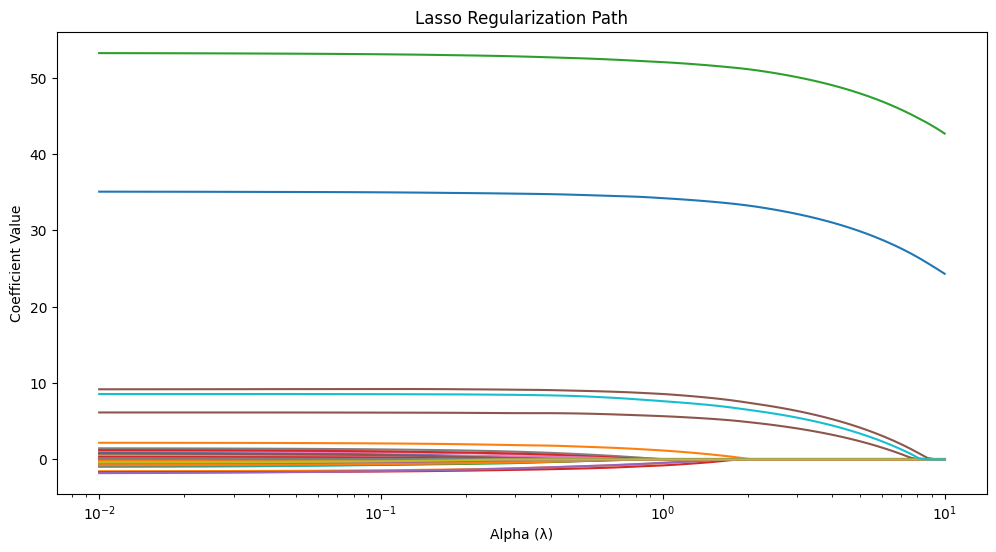

In [12]:
plt.figure(figsize=(12, 6))

for feature_idx in range(X.shape[1]):
    plt.plot(
        alphas_path,
        coefficient_path[:, feature_idx]
    )

plt.xscale("log")

plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regularization Path")

plt.show()

## 13. $L_0$, $L_1$, and $L_2$ Regularization

Different norms have different effects on model coefficients.

### $L_0$

The $L_0$ "norm" counts the number of non-zero coefficients:

$$
\|\beta\|_0
=
\#\{j:\beta_j\neq0\}
$$

An ideal sparse optimization problem is:

$$
\min_\beta
\|y-X\beta\|_2^2
+
\lambda\|\beta\|_0
$$

However, $L_0$ optimization is computationally difficult.

### $L_1$

$$
\|\beta\|_1
=
\sum_j|\beta_j|
$$

Produces sparse solutions and is computationally tractable.

### $L_2$

$$
\|\beta\|_2^2
=
\sum_j\beta_j^2
$$

Shrinks coefficients but generally does not make them exactly zero.

Therefore:

$$
L_0
\rightarrow
\text{ideal sparsity}
$$

$$
L_1
\rightarrow
\text{practical sparse approximation}
$$

$$
L_2
\rightarrow
\text{shrinkage without strong sparsity}
$$

## 14. Ridge vs Lasso

### Ridge Regression

Ridge uses an $L_2$ penalty:

$$
\min_\beta
\frac{1}{2}\|y-X\beta\|_2^2
+
\lambda\|\beta\|_2^2
$$

It shrinks coefficients toward zero.

However, coefficients usually remain non-zero.

### Lasso Regression

Lasso uses an $L_1$ penalty:

$$
\min_\beta
\frac{1}{2}\|y-X\beta\|_2^2
+
\lambda\|\beta\|_1
$$

It can force coefficients exactly to zero.

Therefore:

| Property | Ridge | Lasso |
|---|---|---|
| Regularization | $L_2$ | $L_1$ |
| Shrinks coefficients | Yes | Yes |
| Exact zeros | Usually no | Yes |
| Feature selection | No | Yes |
| Sparse solution | Usually no | Yes |

## 15. Elastic Net

Elastic Net combines $L_1$ and $L_2$ regularization.

Its objective is:

$$
\min_\beta
\frac{1}{2}\|y-X\beta\|_2^2
+
\lambda
\left(
\alpha\|\beta\|_1
+
\frac{1-\alpha}{2}\|\beta\|_2^2
\right)
$$

where:

$$
0 \leq \alpha \leq 1
$$

Interpretation:

$$
\alpha = 1
\Rightarrow
\text{Lasso}
$$

$$
\alpha = 0
\Rightarrow
\text{Ridge-like behavior}
$$

Elastic Net is especially useful when features are highly correlated.

Lasso may select one feature from a group of correlated features, while Elastic Net can retain groups of correlated predictors.

In [13]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_net.fit(X_train_scaled, y_train)

elastic_pred = elastic_net.predict(X_test_scaled)

print("Elastic Net MSE:",
      mean_squared_error(y_test, elastic_pred))

print("Elastic Net R²:",
      r2_score(y_test, elastic_pred))

print(
    "Non-zero coefficients:",
    np.sum(np.abs(elastic_net.coef_) > 1e-6)
)

Elastic Net MSE: 1205.3326246108022
Elastic Net R²: 0.7925309532988266
Non-zero coefficients: 38


## 16. Orthogonal Matching Pursuit

Orthogonal Matching Pursuit (OMP) is a greedy algorithm for finding sparse representations.

Suppose:

$$
y \approx X\beta
$$

OMP starts with no selected features.

At each step it:

1. Finds the feature most correlated with the current residual.
2. Adds that feature to the selected set.
3. Recomputes the coefficients.
4. Updates the residual.
5. Repeats until the desired sparsity is reached.

The process can be summarized as:

$$
\text{Residual}
\rightarrow
\text{Select feature}
\rightarrow
\text{Refit}
\rightarrow
\text{Update residual}
\rightarrow
\text{Repeat}
$$

In [14]:
from sklearn.linear_model import OrthogonalMatchingPursuit

omp = OrthogonalMatchingPursuit(
    n_nonzero_coefs=5
)

omp.fit(X_train_scaled, y_train)

omp_pred = omp.predict(X_test_scaled)

print("OMP MSE:",
      mean_squared_error(y_test, omp_pred))

print("OMP R²:",
      r2_score(y_test, omp_pred))

print(
    "Non-zero coefficients:",
    np.sum(np.abs(omp.coef_) > 1e-6)
)

OMP MSE: 98.52143335125398
OMP R²: 0.9830419027580724
Non-zero coefficients: 5


In [15]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Lasso",
        "Elastic Net",
        "OMP"
    ],
    "MSE": [
        linear_mse,
        lasso_mse,
        mean_squared_error(y_test, elastic_pred),
        mean_squared_error(y_test, omp_pred)
    ],
    "R2": [
        linear_r2,
        lasso_r2,
        r2_score(y_test, elastic_pred),
        r2_score(y_test, omp_pred)
    ],
    "Non-zero Coefficients": [
        linear_nonzero,
        lasso_nonzero,
        np.sum(np.abs(elastic_net.coef_) > 1e-6),
        np.sum(np.abs(omp.coef_) > 1e-6)
    ]
})

comparison

,Model,MSE,R2,Non-zero Coefficients
0,Linear Regression,152.359037,0.973775,50
1,Lasso,126.181866,0.978281,11
2,Elastic Net,1205.332625,0.792531,38
3,OMP,98.521433,0.983042,5


## 17. Comparing Coefficient Sparsity

A useful way to understand sparse modeling is to compare the coefficient vectors of different models.

Dense models tend to use many coefficients.

Sparse models intentionally remove many coefficients by setting them to zero.

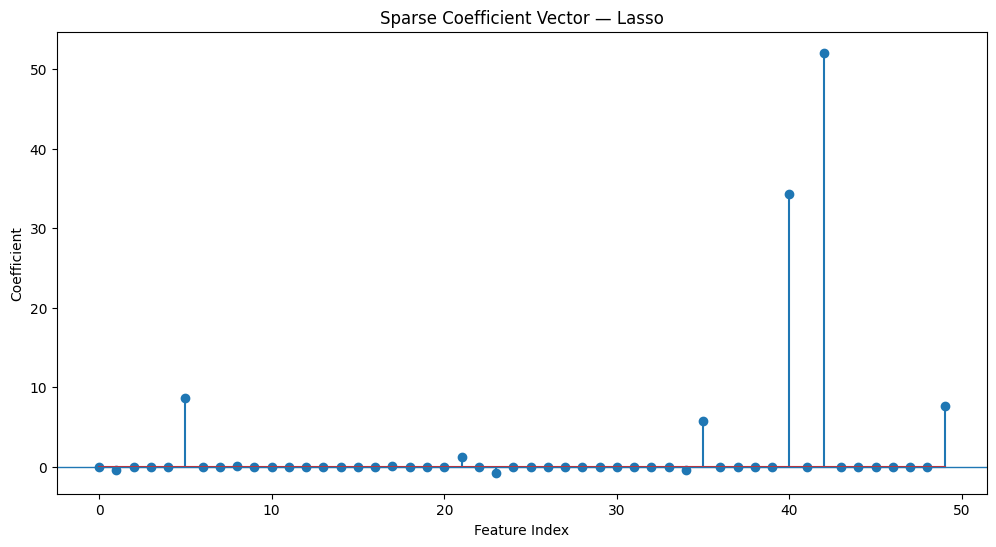

In [16]:
plt.figure(figsize=(12, 6))

plt.stem(
    range(len(lasso.coef_)),
    lasso.coef_
)

plt.axhline(0, linewidth=1)

plt.xlabel("Feature Index")
plt.ylabel("Coefficient")
plt.title("Sparse Coefficient Vector — Lasso")

plt.show()

## 18. Sparsity Level

A useful quantity is the sparsity level.

If there are $d$ total coefficients and $k$ non-zero coefficients:

$$
\text{Sparsity Ratio}
=
1-\frac{k}{d}
$$

For example, if:

$$
d=100
$$

and:

$$
k=10
$$

then:

$$
\text{Sparsity Ratio}
=
1-\frac{10}{100}
=
0.90
$$

Therefore, 90% of the coefficients are zero.

Higher sparsity means a simpler representation.

In [17]:
k = np.sum(np.abs(lasso.coef_) > 1e-6)
d = len(lasso.coef_)

sparsity_ratio = 1 - (k / d)

print("Total coefficients:", d)
print("Non-zero coefficients:", k)
print("Sparsity ratio:", sparsity_ratio)

Total coefficients: 50
Non-zero coefficients: 11
Sparsity ratio: 0.78


## 19. Advantages of Sparse Modeling

### 1. Feature Selection

Sparse models automatically remove irrelevant features.

### 2. Interpretability

A model using 10 features is easier to understand than one using 10,000 features.

### 3. Reduced Overfitting

Removing unnecessary parameters can improve generalization.

### 4. Efficient Prediction

Fewer active features can reduce computational requirements.

### 5. Useful for High-Dimensional Data

Sparse methods are particularly useful when:

$$
d \gg n
$$

where the number of features is much larger than the number of samples.

### 6. Compact Representations

Sparse representations can reduce storage and computational requirements.

## 20. Disadvantages of Sparse Modeling

### 1. Feature Selection Can Be Unstable

When features are highly correlated, small changes in the dataset can change which features are selected.

### 2. Choice of Regularization Matters

The value of $\lambda$ strongly affects the resulting model.

### 3. Excessive Regularization

A very large $\lambda$ can remove useful features and cause underfitting.

### 4. Correlated Features

Lasso may arbitrarily select one feature from a group of highly correlated features.

### 5. Optimization Complexity

Some sparse optimization problems, especially exact $L_0$ optimization, are computationally difficult.

### 6. Scaling Is Important

Regularized models are sensitive to feature scale.

Therefore, numerical features should generally be standardized before applying Lasso or Elastic Net.

## 21. Applications of Sparse Modeling

Sparse modeling is widely used in:

### Genomics

Thousands of genes may be measured while only a small subset is relevant.

### Medical Research

Sparse models can identify important biomarkers.

### Natural Language Processing

Text representations often contain extremely high-dimensional feature spaces.

### Computer Vision

Sparse representations can describe images using a small number of important components.

### Signal Processing

Sparse representations can recover signals from limited measurements.

### Finance

Sparse models can select a small set of relevant predictors.

### Recommender Systems

Sparse matrices naturally occur because users interact with only a small fraction of available items.

### Feature Selection

Sparse models can automatically identify important predictors.

## 22. Sparse Modeling vs Dimensionality Reduction

These concepts are related but different.

### Sparse Modeling

Attempts to keep the original features while setting many coefficients to zero.

Example:

$$
X_1,X_4,X_{27},X_{103}
$$

remain important.

### Dimensionality Reduction

Creates a smaller set of new representations.

For example:

$$
Z_1,Z_2,Z_3
$$

may be combinations of many original features.

Therefore:

$$
\boxed{
\text{Sparse Modeling}
\neq
\text{Dimensionality Reduction}
}
$$

Sparse modeling emphasizes **feature selection and sparse parameters**.

Dimensionality reduction emphasizes **representing data in a lower-dimensional space**.

## 23. Sparse Modeling Workflow

A typical sparse modeling workflow is:

$$
\text{Raw Data}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Feature Scaling}
\rightarrow
\text{Train Sparse Model}
\rightarrow
\text{Tune Regularization}
\rightarrow
\text{Feature Selection}
\rightarrow
\text{Evaluation}
$$

### Step 1 — Prepare Data

Handle missing values and categorical variables.

### Step 2 — Scale Features

Standardize numerical features when appropriate.

### Step 3 — Choose Sparse Method

Examples:

- Lasso
- Elastic Net
- OMP

### Step 4 — Tune Hyperparameters

Use cross-validation to select $\lambda$ or other sparsity parameters.

### Step 5 — Examine Selected Features

Identify coefficients that are non-zero.

### Step 6 — Evaluate

Evaluate both:

- predictive performance
- sparsity

A model should not be judged only by accuracy.

## 24. Key Takeaways

1. Sparse modeling tries to learn models with many zero coefficients.

2. Lasso uses $L_1$ regularization:

$$
\min_\beta
\frac{1}{2}\|y-X\beta\|_2^2
+
\lambda\|\beta\|_1
$$

3. $L_1$ regularization can produce exact zeros.

4. Therefore, Lasso can perform feature selection.

5. Increasing $\lambda$ generally increases sparsity.

6. Elastic Net combines $L_1$ and $L_2$ regularization.

7. Orthogonal Matching Pursuit is a greedy approach to sparse representation.

8. Sparse modeling is especially useful for high-dimensional datasets.

9. Feature scaling is important for regularized models.

10. Hyperparameters should generally be selected using cross-validation.

The central idea is:

$$
\boxed{
\text{Useful model}
=
\text{Good prediction}
+
\text{Controlled complexity}
+
\text{Sparsity}
}
$$

# Final Summary

Sparse modeling provides a principled way to build models using only a small number of important parameters.

The most important idea to remember is:

$$
\boxed{
\text{Sparsity means many model parameters are exactly zero}
}
$$

The key techniques are:

| Method | Main Idea |
|---|---|
| Lasso | $L_1$ regularization |
| Elastic Net | $L_1 + L_2$ regularization |
| OMP | Greedy sparse feature selection |
| Basis Pursuit | Optimization for sparse representation |

Most importantly:

$$
L_1
\rightarrow
\text{Sparsity}
\rightarrow
\text{Feature Selection}
$$

This makes sparse modeling an important connection between **regularization, feature selection, optimization, and high-dimensional machine learning**.